# EE0848 Week 5 Practice

In this session, we will practice:
- Data Preprocessing (Scaling)
- Building Pipelines
- Cross Validation
- Hyperparameter Tuning using GridSearchCV

We will work with the Breast Cancer Wisconsin dataset to build a logistic regression model with polynomial features.


In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the Breast Cancer Wisconsin dataset from UCI repository
# Note: The dataset does not include headers, so we set header=None
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data', header=None)


## Data Preparation

We extract the design matrix (features) and the target vector (labels).

- **Features (X):** All columns from index 2 onward.
- **Labels (y):** Column at index 1.  
  We pandas to convert the labels ('M' for malignant, 'B' for benign) into numeric values:
  - Manual mapping using pandas' `map()`.


In [ ]:
# Extract features starting from the 3rd column onward
X = df.iloc[:, 2:].values

# Convert string labels to numeric values manually:
# 'M' -> 0 (malignant), 'B' -> 1 (benign)
y = df.iloc[:, 1].map({'M': 0, 'B': 1}).values

## Building the Pipeline

We will create a pipeline that:
1. Scales the data using `StandardScaler`.
2. Generates polynomial features (degree 2) with only interaction terms.
3. Applies logistic regression with a specified regularization parameter C.

We then evaluate the model on a hold-out test set.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# URL for the compressed Higgs dataset
higgs_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz"

# Define column names: first column is the label, followed by 28 features (total 29 columns)
columns = ['label'] + [f'feature_{i}' for i in range(1, 29)]

# Load a subset of the dataset for initial exploration (e.g., first 100,000 rows)
df_higgs = pd.read_csv(higgs_url, header=None, names=columns, compression='gzip', nrows=10000)

# Display basic information about the dataset
print(df_higgs.head())
print("Data shape:", df_higgs.shape)

# Separate features (X) and target (y)
X = df_higgs.drop('label', axis=1)
y = df_higgs['label']

# Split the data into training and test sets (e.g., 80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Build a pipeline: scaling -> polynomial features -> logistic regression
pipe_log = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    LogisticRegression(C=10, max_iter=10000)
)

# Fit the pipeline on the training data
pipe_log.fit(X_train, y_train)

# Predict on the test set and calculate accuracy
y_pred = pipe_log.predict(X_test)
test_acc = pipe_log.score(X_test, y_test)
print(f'Test accuracy: {test_acc:.3f}')


   label  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0    1.0   0.869293  -0.635082   0.225690   0.327470  -0.689993   0.754202   
1    1.0   0.907542   0.329147   0.359412   1.497970  -0.313010   1.095531   
2    1.0   0.798835   1.470639  -1.635975   0.453773   0.425629   1.104875   
3    0.0   1.344385  -0.876626   0.935913   1.992050   0.882454   1.786066   
4    1.0   1.105009   0.321356   1.522401   0.882808  -1.205349   0.681466   

   feature_7  feature_8  feature_9  ...  feature_19  feature_20  feature_21  \
0  -0.248573  -1.092064   0.000000  ...   -0.010455   -0.045767    3.101961   
1  -0.557525  -1.588230   2.173076  ...   -1.138930   -0.000819    0.000000   
2   1.282322   1.381664   0.000000  ...    1.128848    0.900461    0.000000   
3  -1.646778  -0.942383   0.000000  ...   -0.678379   -1.360356    0.000000   
4  -1.070464  -0.921871   0.000000  ...   -0.373566    0.113041    0.000000   

   feature_22  feature_23  feature_24  feature_25  featu

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Split the data into training and testing sets (stratified to maintain label proportions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

# Build a pipeline: scaling -> polynomial features -> logistic regression
pipe_log = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    LogisticRegression(C=10, max_iter=10000)
)

# Fit the pipeline on the training data
pipe_log.fit(X_train, y_train)

# Predict on the test set and calculate accuracy
y_pred = pipe_log.predict(X_test)
test_acc = pipe_log.score(X_test, y_test)
print(f'Test accuracy: {test_acc:.3f}')

Test accuracy: 0.956


## Manual Hyperparameter Tuning

Next, we perform a manual search for the best regularization parameter C by:
1. Splitting the data into training, validation, and test sets.
2. Iterating over a range of C values.
3. Evaluating performance on the validation set.

This helps us understand the effect of C on model performance.

In [ ]:
# Split the data: training+validation and test
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

# Further split training+validation into separate training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=123)

# Define the range of C values to try (logarithmically spaced)
C_values = np.logspace(-5, 4, 10)
train_scores = []
val_scores = []

# Loop over each C value, build the pipeline, fit, and evaluate on the validation set
for c in C_values:
    pipe_log = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
        LogisticRegression(C=c, max_iter=10000)
    )
    pipe_log.fit(X_train, y_train)
    train_scores.append(pipe_log.score(X_train,y_train))
    val_scores.append(pipe_log.score(X_test,y_test))

# Identify the best C value based on validation accuracy
best_C = C_values[np.argmax(val_scores)]
print(f'The best C value: {best_C}')


The best C value: 0.01


In [ ]:
# Rebuild the pipeline with the best C value and train on combined training+validation data
pipe_log = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    LogisticRegression(C=best_C, max_iter=10000)
)
pipe_log.fit(X_trainval, y_trainval)

# Evaluate the final model on the test set
final_score = pipe_log.score(X_test, y_test)
print(f'Final test accuracy: {final_score:.3f}')


Final test accuracy: 0.982


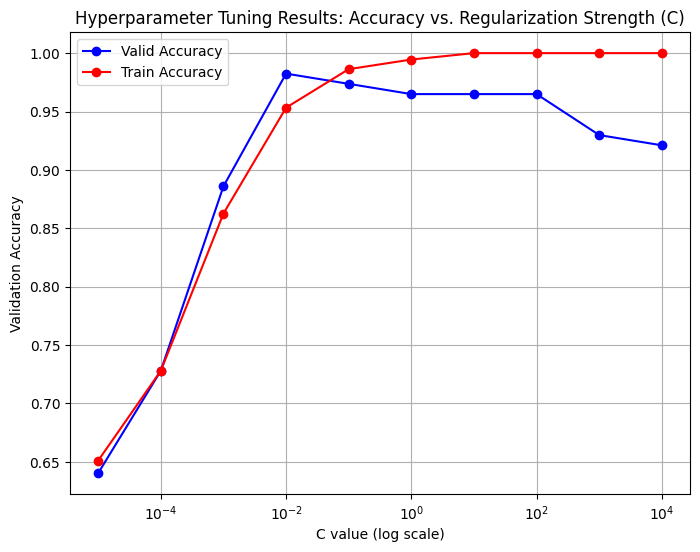

In [ ]:
import matplotlib.pyplot as plt

# Plot the validation accuracy vs. regularization strength (C)
plt.figure(figsize=(8, 6))
plt.semilogx(C_values, val_scores, marker='o', color='b',label='Valid Accuracy')
plt.semilogx(C_values, train_scores, marker='o', color='r',label='Train Accuracy')
plt.xlabel('C value (log scale)')
plt.ylabel('Validation Accuracy')
plt.title('Hyperparameter Tuning Results: Accuracy vs. Regularization Strength (C)')
plt.grid(True)
plt.legend()
plt.show()

## GridSearchCV for Integrated Hyperparameter Tuning

Finally, we use `GridSearchCV` to combine cross validation with hyperparameter tuning in one step.
We search over both the C parameter and the regularization penalty (L1 and L2) this time.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Build a pipeline with LogisticRegression using 'liblinear' solver (supports both L1 and L2)
pipe_log = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    LogisticRegression(max_iter=10000, solver='liblinear')
)

# Define the parameter grid for GridSearchCV
param_grid = {
    'logisticregression__C': np.logspace(-5, 4, 10),
    'logisticregression__penalty': ['l1', 'l2']
}

# Set up GridSearchCV with 5-fold cross validation
grid = GridSearchCV(pipe_log, param_grid, cv=10)
grid.fit(X_train, y_train)

# Output the best parameters and test set score
print("Best parameters from GridSearchCV:", grid.best_params_)
print("Test set accuracy with best parameters:", grid.score(X_test, y_test))


Best parameters from GridSearchCV: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l1'}
Test set accuracy with best parameters: 0.9736842105263158


In [ ]:
# Rebuild the pipeline with the best C value and train on combined training+validation data
pipe_log = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    LogisticRegression(C=0.1, penalty='l1',max_iter=10000, solver='liblinear')
)
pipe_log.fit(X_trainval, y_trainval)

# Evaluate the final model on the test set
final_score = pipe_log.score(X_test, y_test)
print(f'Final test accuracy: {final_score:.3f}')

Final test accuracy: 0.982


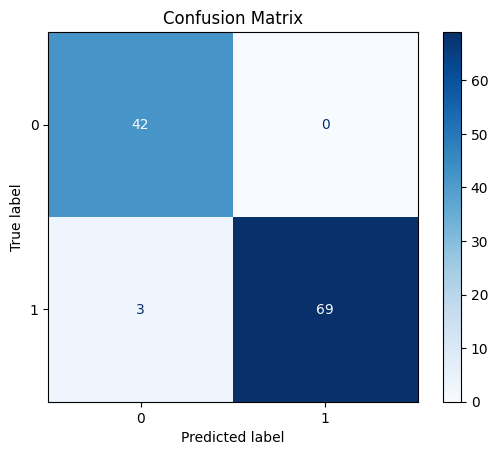

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions for the test set
y_pred = grid.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a confusion matrix display object and plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Get predictions on the test set
y_pred = pipe_log.predict(X_test)

# Generate and print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        42
           1       1.00      0.97      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114



## Summary and Takeaways

- **Preprocessing:** Scaling is crucial for models using regularization.
- **Pipelines:** They simplify the workflow by chaining preprocessing and model training steps.
- **Hyperparameter Tuning:** Both manual search and GridSearchCV help find the optimal settings.
- **Cross Validation:** Provides a robust estimate of model performance across different splits.

This notebook demonstrated how to integrate these concepts to build a robust machine learning model.
